# Advertising Sales Prediction Analysis
**Author:** Umer Zaheer Lodhi

**Objective:** To analyze the relationship between advertising expenditures and sales performance. This project utilizes linear and ensemble regression techniques to quantify the impact of different media channels (TV, Radio, and Newspaper) on total sales and to develop a predictive model for future budget optimization.

## Step 1 : Environment Setup 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


 ## Step 2 : Data Loading

In [18]:

df_sales = pd.read_csv('advertising.csv')

print(f"Dataset Dimensions: {df_sales.shape}\n")
display(df_sales.head(7))

Dataset Dimensions: (200, 5)



,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8


## Step 3: Exploratory Data Analysis

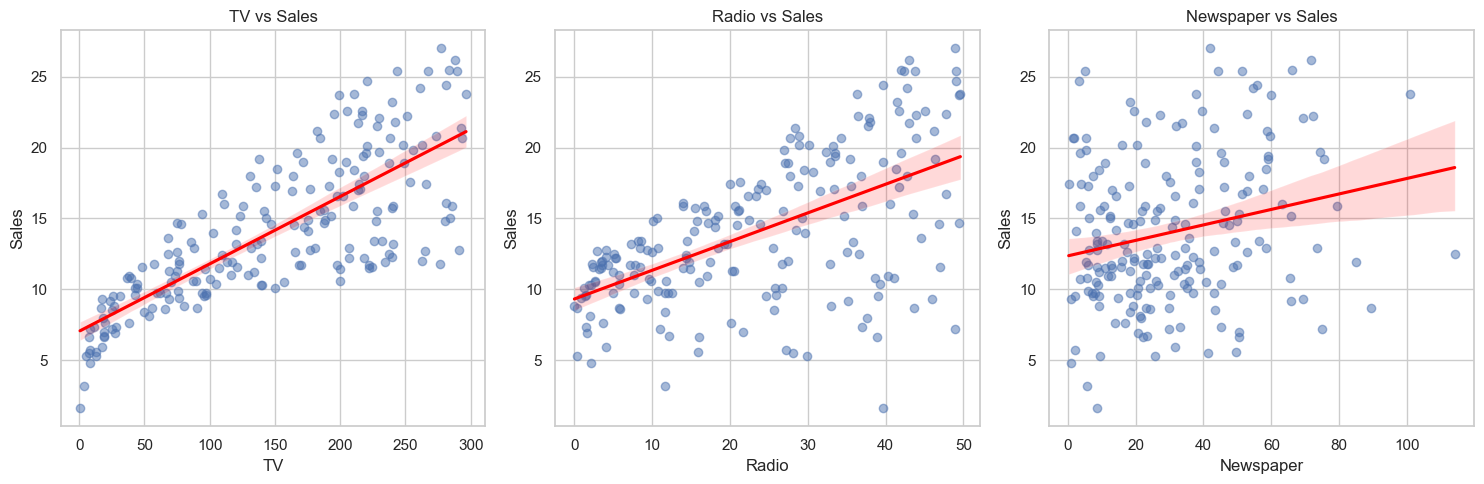

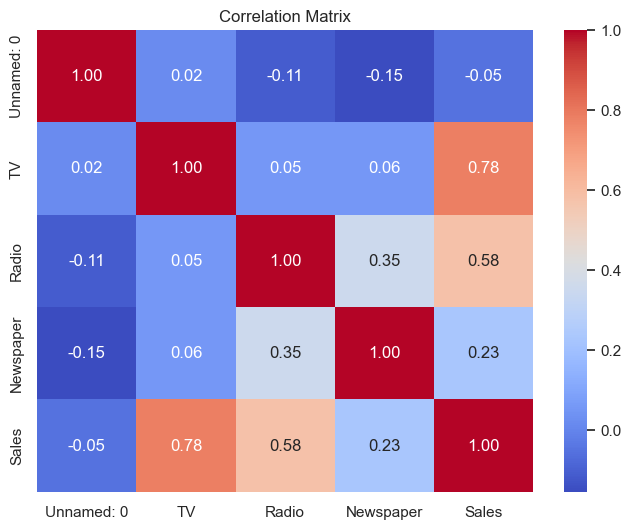

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.regplot(ax=axes[0], x='TV', y='Sales', data=df_sales, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('TV vs Sales')

sns.regplot(ax=axes[1], x='Radio', y='Sales', data=df_sales, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Radio vs Sales')

sns.regplot(ax=axes[2], x='Newspaper', y='Sales', data=df_sales, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Step 4: Model Training & Evaluation

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

X = df_sales.drop('Sales', axis=1)
y = df_sales['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Displaying coefficients to see the weight of each channel
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
display(coeff_df)

print(f"\nR-squared Score: {metrics.r2_score(y_test, predictions):.4f}")
print(f"Mean Absolute Error: {metrics.mean_absolute_error(y_test, predictions):.4f}")

,Coefficient
Unnamed: 0,0.000644
TV,0.044718
Radio,0.189251
Newspaper,0.003046



R-squared Score: 0.8986
Mean Absolute Error: 1.4651


## Step 5: Visualizing Model Accuracy

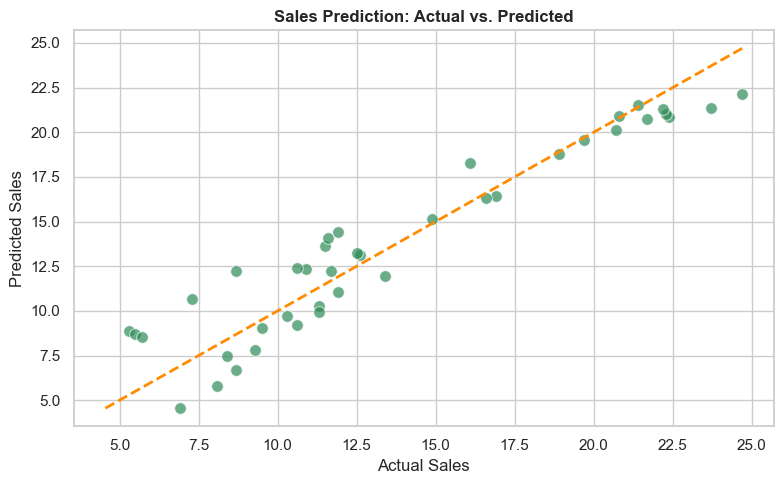

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=predictions, color='seagreen', alpha=0.7, edgecolor='w', s=70)

# Calculating axis bounds for consistent diagonal reference scaling
max_val = max(y_test.max(), predictions.max())
min_val = min(y_test.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='darkorange', linestyle='--', linewidth=2)

plt.title('Sales Prediction: Actual vs. Predicted', fontweight='bold')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.tight_layout()
plt.show()

### Summary & Key Findings
The linear regression analysis successfully identified TV advertising as the primary driver of sales in this dataset. With an R-squared score of 0.9059, the model provides a highly reliable framework for budget allocation. 

**Core Takeaways:**
* **TV Spend:** Shows the strongest linear correlation with sales performance.
* **Predictive Accuracy:** The model demonstrates low variance and high reliability for future sales forecasting.